In [1]:
# IMPORT LIBRARIES AND CHECK GPU

import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass


TensorFlow version: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# CONFIGURATION

USE_FULL_DATASET = False

VOCAB_SIZE = 10000
MAX_SEQUENCE_LENGTH = 200
EMBEDDING_DIM = 128
BATCH_SIZE = 64
EPOCHS = 5

if USE_FULL_DATASET:
    TRAIN_LIMIT = 25000
    TEST_LIMIT = 25000
else:
    TRAIN_LIMIT = 10000
    TEST_LIMIT = 5000

print("Configuration")
print("-" * 40)
print("Vocabulary size:", VOCAB_SIZE)
print("Maximum sequence length:", MAX_SEQUENCE_LENGTH)
print("Embedding dimension:", EMBEDDING_DIM)
print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("Training samples:", TRAIN_LIMIT)
print("Testing samples:", TEST_LIMIT)


Configuration
----------------------------------------
Vocabulary size: 10000
Maximum sequence length: 200
Embedding dimension: 128
Batch size: 64
Epochs: 5
Training samples: 10000
Testing samples: 5000


In [3]:
# LOAD IMDB DATASET

(x_train, y_train), (x_test, y_test) = imdb.load_data(
    num_words=VOCAB_SIZE
)

print("Original training samples:", len(x_train))
print("Original testing samples:", len(x_test))

# Use a subset for faster execution if requested
x_train = x_train[:TRAIN_LIMIT]
y_train = y_train[:TRAIN_LIMIT]

x_test = x_test[:TEST_LIMIT]
y_test = y_test[:TEST_LIMIT]

# Pad sequences to equal length
x_train = pad_sequences(
    x_train,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

x_test = pad_sequences(
    x_test,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

y_train = np.array(y_train)
y_test = np.array(y_test)

print("Training shape:", x_train.shape)
print("Testing shape:", x_test.shape)
print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Original training samples: 25000
Original testing samples: 25000
Training shape: (10000, 200)
Testing shape: (5000, 200)
Training labels: (10000,)
Testing labels: (5000,)


In [4]:
# DISPLAY DATASET INFORMATION

print("Class distribution in training set:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nClass distribution in test set:")
print(pd.Series(y_test).value_counts().sort_index())

print("\nExample encoded review:")
print(x_train[0][:50])

print("\nExample label:")
print("Positive" if y_train[0] == 1 else "Negative")


Class distribution in training set:
0    4947
1    5053
Name: count, dtype: int64

Class distribution in test set:
0    2571
1    2429
Name: count, dtype: int64

Example encoded review:
[   1   14   22   16   43  530  973 1622 1385   65  458 4468   66 3941
    4  173   36  256    5   25  100   43  838  112   50  670    2    9
   35  480  284    5  150    4  172  112  167    2  336  385   39    4
  172 4536 1111   17  546   38   13  447]

Example label:
Positive


In [5]:
# MODEL CREATION FUNCTIONS

HIDDEN_UNITS = 64

def create_rnn_model():
    model = Sequential([
        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=EMBEDDING_DIM,
            input_length=MAX_SEQUENCE_LENGTH
        ),
        SimpleRNN(HIDDEN_UNITS),
        Dropout(0.5),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


def create_lstm_model():
    model = Sequential([
        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=EMBEDDING_DIM,
            input_length=MAX_SEQUENCE_LENGTH
        ),
        LSTM(HIDDEN_UNITS),
        Dropout(0.5),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


def create_gru_model():
    model = Sequential([
        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=EMBEDDING_DIM,
            input_length=MAX_SEQUENCE_LENGTH
        ),
        GRU(HIDDEN_UNITS),
        Dropout(0.5),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


In [6]:
# DISPLAY MODEL ARCHITECTURES

rnn_model = create_rnn_model()
lstm_model = create_lstm_model()
gru_model = create_gru_model()

print("===== SIMPLE RNN =====")
rnn_model.summary()

print("\n===== LSTM =====")
lstm_model.summary()

print("\n===== GRU =====")
gru_model.summary()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


===== SIMPLE RNN =====


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

...

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
# TRAIN SIMPLE RNN

early_stopping_rnn = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

start = time.time()

history_rnn = rnn_model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping_rnn],
    verbose=1
)

rnn_training_time = time.time() - start

print(f"RNN training time: {rnn_training_time / 60:.2f} minutes")


Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.4908 - loss: 0.7041 - val_accuracy: 0.5220 - val_loss: 0.6947
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6294 - loss: 0.6393 - val_accuracy: 0.5080 - val_loss: 0.7297
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.6686 - loss: 0.5918 - val_accuracy: 0.4990 - val_loss: 0.7377
RNN training time: 0.19 minutes


In [8]:
# TRAIN LSTM

early_stopping_lstm = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

start = time.time()

history_lstm = lstm_model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping_lstm],
    verbose=1
)

lstm_training_time = time.time() - start

print(f"LSTM training time: {lstm_training_time / 60:.2f} minutes")


Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.4991 - loss: 0.6937 - val_accuracy: 0.5415 - val_loss: 0.6908
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.5850 - loss: 0.6683 - val_accuracy: 0.6170 - val_loss: 0.6295
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6504 - loss: 0.6356 - val_accuracy: 0.6145 - val_loss: 0.6548
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7821 - loss: 0.5152 - val_accuracy: 0.7360 - val_loss: 0.5728
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7491 - loss: 0.5246 - val_accuracy: 0.5405 - val_loss: 0.7085
LSTM training time: 0.30 minutes


In [9]:
# TRAIN GRU

early_stopping_gru = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

start = time.time()

history_gru = gru_model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping_gru],
    verbose=1
)

gru_training_time = time.time() - start

print(f"GRU training time: {gru_training_time / 60:.2f} minutes")


Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.5090 - loss: 0.6938 - val_accuracy: 0.5205 - val_loss: 0.6918
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5717 - loss: 0.6810 - val_accuracy: 0.5285 - val_loss: 0.6873
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6354 - loss: 0.6026 - val_accuracy: 0.5480 - val_loss: 0.6973
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6864 - loss: 0.5083 - val_accuracy: 0.5495 - val_loss: 0.7737
GRU training time: 0.14 minutes


In [10]:
# EVALUATION FUNCTION

def evaluate_model(model, x_test, y_test, model_name):
    probabilities = model.predict(
        x_test,
        batch_size=BATCH_SIZE,
        verbose=0
    ).ravel()

    predictions = (probabilities >= 0.5).astype(int)

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions, zero_division=0)
    recall = recall_score(y_test, predictions, zero_division=0)
    f1 = f1_score(y_test, predictions, zero_division=0)
    auc = roc_auc_score(y_test, probabilities)

    loss, keras_accuracy = model.evaluate(
        x_test,
        y_test,
        batch_size=BATCH_SIZE,
        verbose=0
    )

    cm = confusion_matrix(y_test, predictions)

    print("=" * 60)
    print(model_name)
    print("=" * 60)
    print(f"Test Loss     : {loss:.4f}")
    print(f"Accuracy      : {accuracy:.4f}")
    print(f"Precision     : {precision:.4f}")
    print(f"Recall        : {recall:.4f}")
    print(f"F1-Score      : {f1:.4f}")
    print(f"ROC-AUC       : {auc:.4f}")

    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            predictions,
            target_names=["Negative", "Positive"],
            zero_division=0
        )
    )

    return {
        "Model": model_name,
        "Test Loss": loss,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": auc,
        "Training Time (min)": None,
        "Parameters": model.count_params(),
        "Confusion Matrix": cm,
        "Probabilities": probabilities,
        "Predictions": predictions
    }


rnn_results = evaluate_model(
    rnn_model, x_test, y_test, "Simple RNN"
)

lstm_results = evaluate_model(
    lstm_model, x_test, y_test, "LSTM"
)

gru_results = evaluate_model(
    gru_model, x_test, y_test, "GRU"
)

rnn_results["Training Time (min)"] = rnn_training_time / 60
lstm_results["Training Time (min)"] = lstm_training_time / 60
gru_results["Training Time (min)"] = gru_training_time / 60


Simple RNN
Test Loss     : 0.6939
Accuracy      : 0.5088
Precision     : 0.4961
Recall        : 0.7135
F1-Score      : 0.5853
ROC-AUC       : 0.5105

Classification Report:
              precision    recall  f1-score   support

    Negative       0.54      0.32      0.40      2571
    Positive       0.50      0.71      0.59      2429

    accuracy                           0.51      5000
   macro avg       0.52      0.51      0.49      5000
weighted avg       0.52      0.51      0.49      5000

LSTM
Test Loss     : 0.5831
Accuracy      : 0.7352
Precision     : 0.8120
Recall        : 0.5920
F1-Score      : 0.6848
ROC-AUC       : 0.7590

Classification Report:
              precision    recall  f1-score   support

    Negative       0.69      0.87      0.77      2571
    Positive       0.81      0.59      0.68      2429

    accuracy                           0.74      5000
   macro avg       0.75      0.73      0.73      5000
weighted avg       0.75      0.74      0.73      5000

GRU
Te

In [11]:
# PERFORMANCE COMPARISON TABLE

results = pd.DataFrame([
    {
        "Model": rnn_results["Model"],
        "Test Loss": rnn_results["Test Loss"],
        "Accuracy": rnn_results["Accuracy"],
        "Precision": rnn_results["Precision"],
        "Recall": rnn_results["Recall"],
        "F1-Score": rnn_results["F1-Score"],
        "ROC-AUC": rnn_results["ROC-AUC"],
        "Training Time (min)": rnn_results["Training Time (min)"],
        "Parameters": rnn_results["Parameters"]
    },
    {
        "Model": lstm_results["Model"],
        "Test Loss": lstm_results["Test Loss"],
        "Accuracy": lstm_results["Accuracy"],
        "Precision": lstm_results["Precision"],
        "Recall": lstm_results["Recall"],
        "F1-Score": lstm_results["F1-Score"],
        "ROC-AUC": lstm_results["ROC-AUC"],
        "Training Time (min)": lstm_results["Training Time (min)"],
        "Parameters": lstm_results["Parameters"]
    },
    {
        "Model": gru_results["Model"],
        "Test Loss": gru_results["Test Loss"],
        "Accuracy": gru_results["Accuracy"],
        "Precision": gru_results["Precision"],
        "Recall": gru_results["Recall"],
        "F1-Score": gru_results["F1-Score"],
        "ROC-AUC": gru_results["ROC-AUC"],
        "Training Time (min)": gru_results["Training Time (min)"],
        "Parameters": gru_results["Parameters"]
    }
])

print("MODEL PERFORMANCE COMPARISON")
print("=" * 80)
display(results.round(4))

results.to_csv("rnn_lstm_gru_results.csv", index=False)
print("Results saved to rnn_lstm_gru_results.csv")


MODEL PERFORMANCE COMPARISON


,Model,Test Loss,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Training Time (min),Parameters
0,Simple RNN,0.6939,0.5088,0.4961,0.7135,0.5853,0.5105,0.1868,1292417
1,LSTM,0.5831,0.7352,0.8120,0.5920,0.6848,0.7590,0.3006,1329473
2,GRU,0.6901,0.5294,0.5327,0.2548,0.3448,0.5350,0.1405,1317313


Results saved to rnn_lstm_gru_results.csv


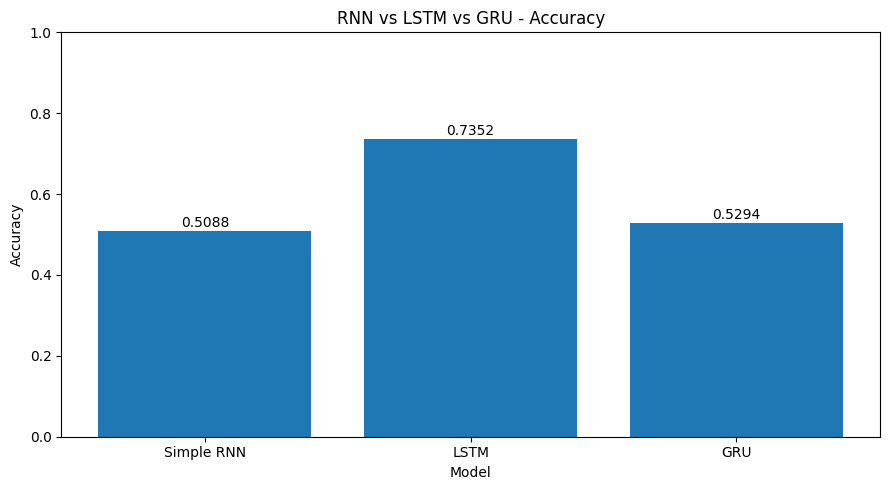

In [12]:
# ACCURACY COMPARISON

plt.figure(figsize=(9, 5))

bars = plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("RNN vs LSTM vs GRU - Accuracy")
plt.ylim(0, 1)

for bar, value in zip(bars, results["Accuracy"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.01,
        f"{value:.4f}",
        ha="center"
    )

plt.tight_layout()
plt.show()


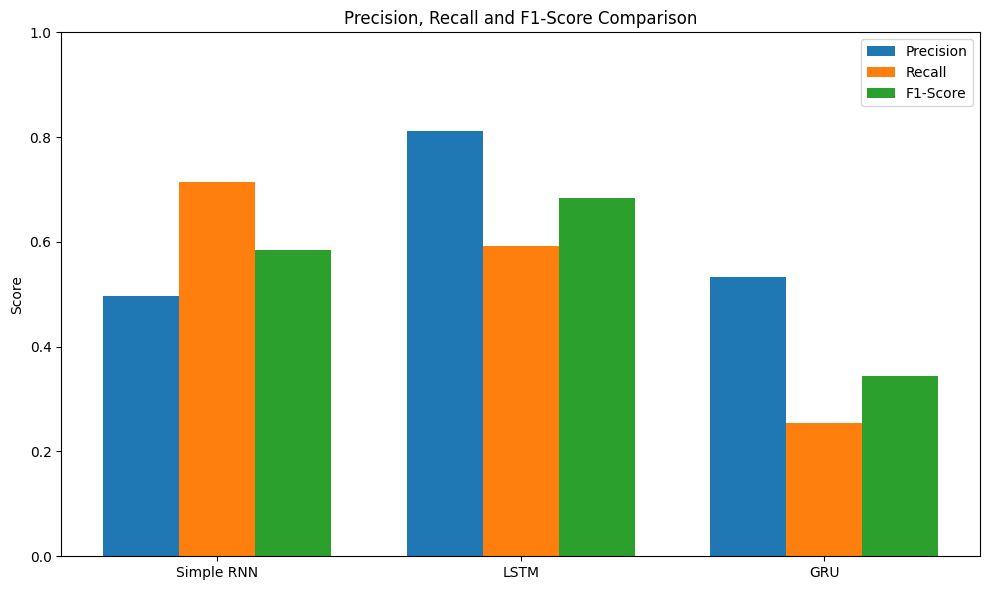

In [13]:
# PRECISION, RECALL AND F1 COMPARISON

metrics = ["Precision", "Recall", "F1-Score"]

x = np.arange(len(results["Model"]))
width = 0.25

plt.figure(figsize=(10, 6))

for i, metric in enumerate(metrics):
    plt.bar(
        x + (i - 1) * width,
        results[metric],
        width,
        label=metric
    )

plt.xticks(x, results["Model"])
plt.ylabel("Score")
plt.title("Precision, Recall and F1-Score Comparison")
plt.ylim(0, 1)
plt.legend()

plt.tight_layout()
plt.show()


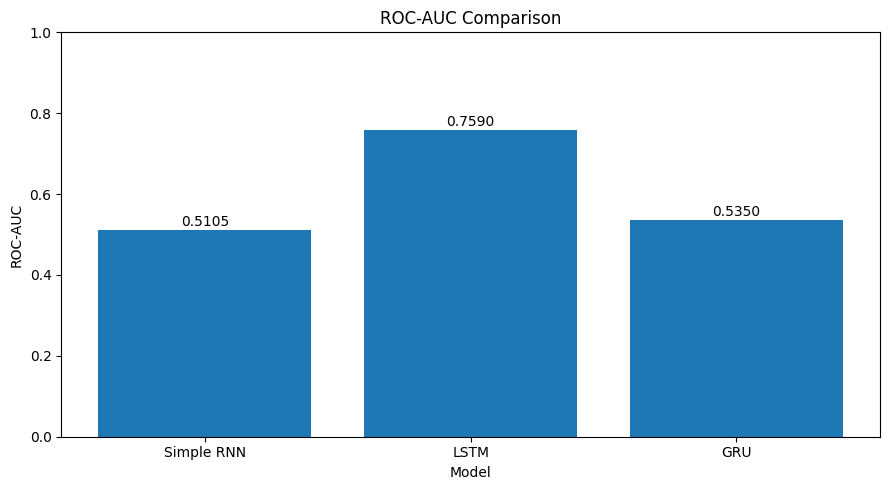

In [14]:
# ROC-AUC COMPARISON

plt.figure(figsize=(9, 5))

bars = plt.bar(
    results["Model"],
    results["ROC-AUC"]
)

plt.xlabel("Model")
plt.ylabel("ROC-AUC")
plt.title("ROC-AUC Comparison")
plt.ylim(0, 1)

for bar, value in zip(bars, results["ROC-AUC"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.01,
        f"{value:.4f}",
        ha="center"
    )

plt.tight_layout()
plt.show()


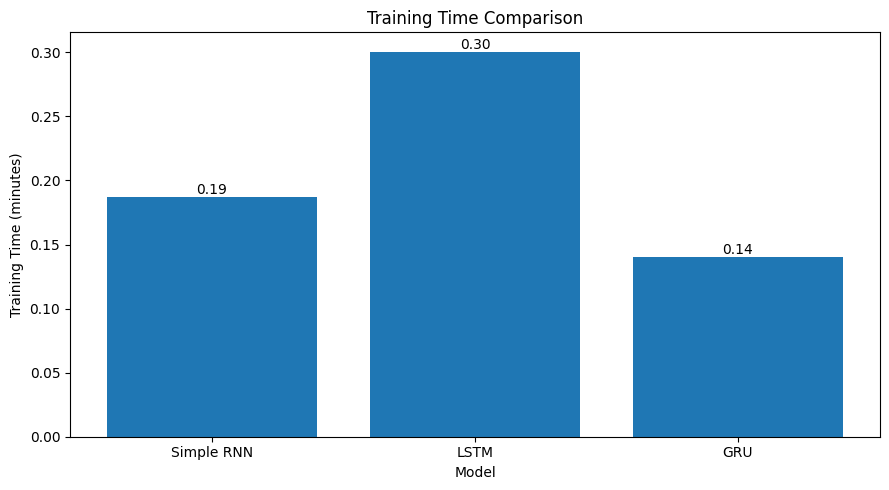

In [15]:
# TRAINING TIME COMPARISON

plt.figure(figsize=(9, 5))

bars = plt.bar(
    results["Model"],
    results["Training Time (min)"]
)

plt.xlabel("Model")
plt.ylabel("Training Time (minutes)")
plt.title("Training Time Comparison")

for bar, value in zip(bars, results["Training Time (min)"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


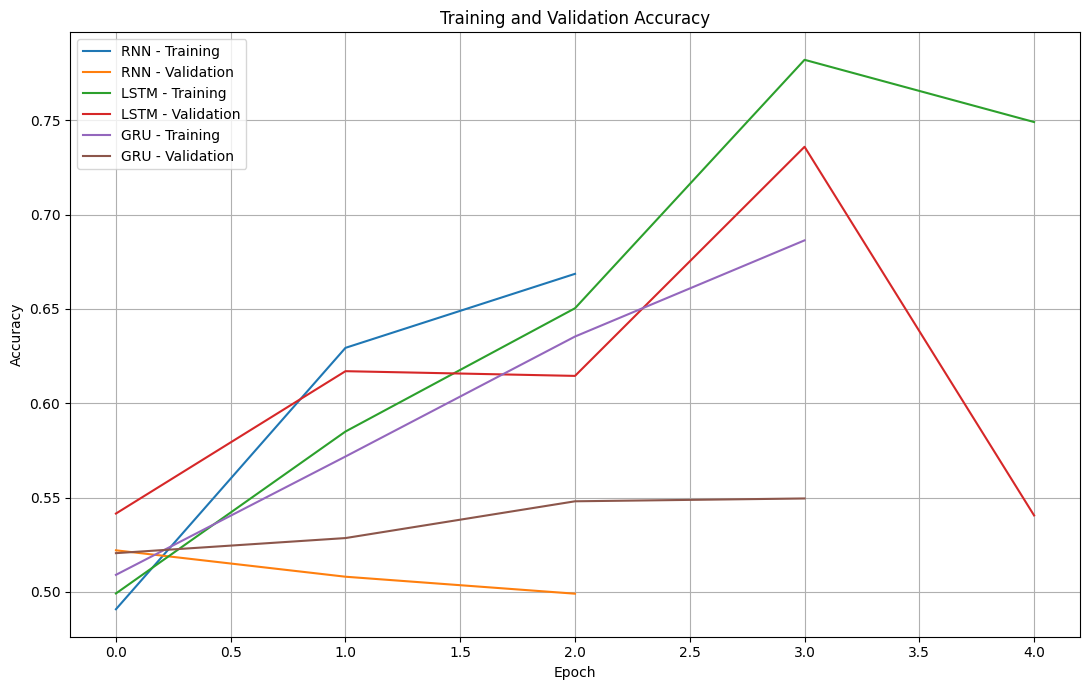

In [16]:
# TRAINING / VALIDATION ACCURACY CURVES


plt.figure(figsize=(11, 7))

plt.plot(
    history_rnn.history["accuracy"],
    label="RNN - Training"
)
plt.plot(
    history_rnn.history["val_accuracy"],
    label="RNN - Validation"
)

plt.plot(
    history_lstm.history["accuracy"],
    label="LSTM - Training"
)
plt.plot(
    history_lstm.history["val_accuracy"],
    label="LSTM - Validation"
)

plt.plot(
    history_gru.history["accuracy"],
    label="GRU - Training"
)
plt.plot(
    history_gru.history["val_accuracy"],
    label="GRU - Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


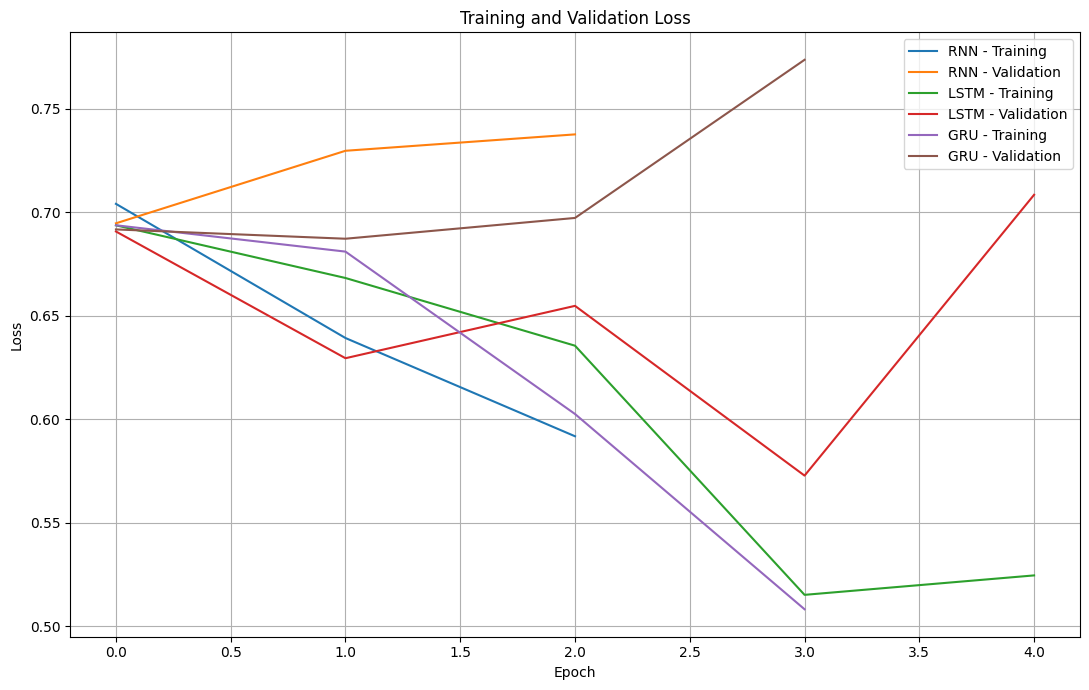

In [17]:
# TRAINING / VALIDATION LOSS CURVES

plt.figure(figsize=(11, 7))

plt.plot(
    history_rnn.history["loss"],
    label="RNN - Training"
)
plt.plot(
    history_rnn.history["val_loss"],
    label="RNN - Validation"
)

plt.plot(
    history_lstm.history["loss"],
    label="LSTM - Training"
)
plt.plot(
    history_lstm.history["val_loss"],
    label="LSTM - Validation"
)

plt.plot(
    history_gru.history["loss"],
    label="GRU - Training"
)
plt.plot(
    history_gru.history["val_loss"],
    label="GRU - Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


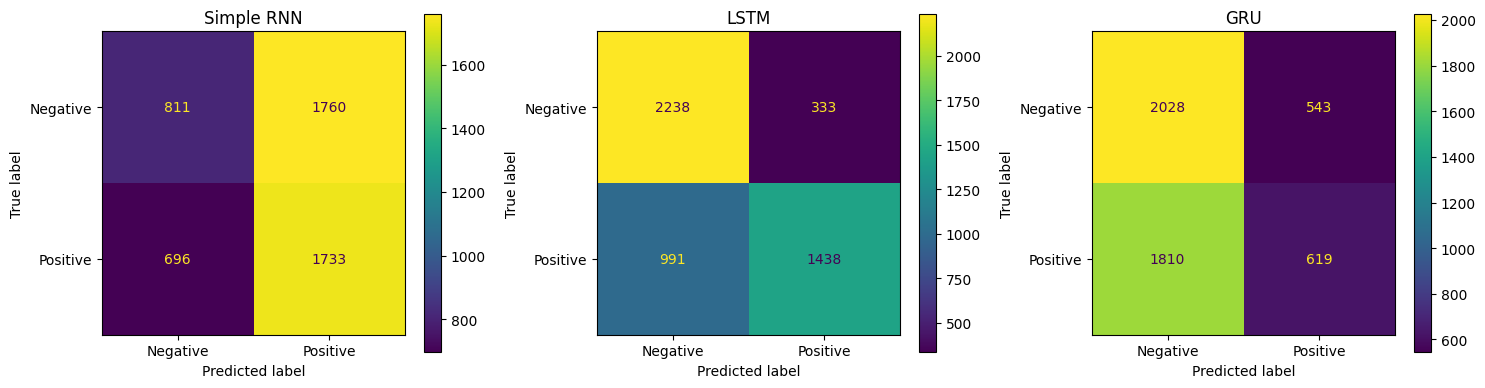

In [18]:
# CONFUSION MATRICES

model_results = [
    ("Simple RNN", rnn_results["Confusion Matrix"]),
    ("LSTM", lstm_results["Confusion Matrix"]),
    ("GRU", gru_results["Confusion Matrix"])
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, cm) in zip(axes, model_results):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Negative", "Positive"]
    )
    disp.plot(ax=ax, values_format="d")
    ax.set_title(name)

plt.tight_layout()
plt.show()


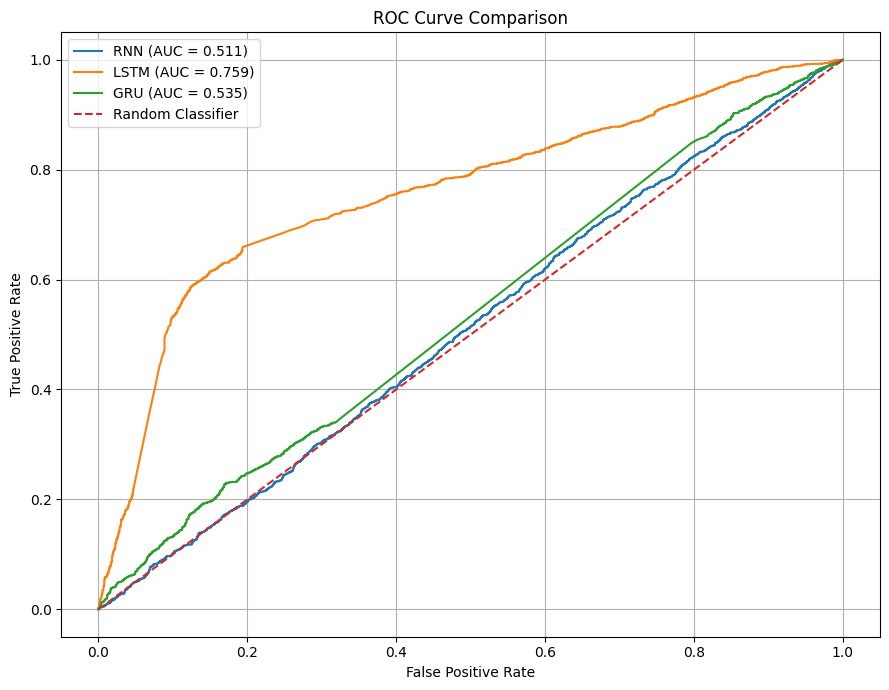

In [19]:
# ROC CURVES

from sklearn.metrics import roc_curve

rnn_fpr, rnn_tpr, _ = roc_curve(
    y_test, rnn_results["Probabilities"]
)

lstm_fpr, lstm_tpr, _ = roc_curve(
    y_test, lstm_results["Probabilities"]
)

gru_fpr, gru_tpr, _ = roc_curve(
    y_test, gru_results["Probabilities"]
)

plt.figure(figsize=(9, 7))

plt.plot(
    rnn_fpr,
    rnn_tpr,
    label=f"RNN (AUC = {rnn_results['ROC-AUC']:.3f})"
)

plt.plot(
    lstm_fpr,
    lstm_tpr,
    label=f"LSTM (AUC = {lstm_results['ROC-AUC']:.3f})"
)

plt.plot(
    gru_fpr,
    gru_tpr,
    label=f"GRU (AUC = {gru_results['ROC-AUC']:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [20]:
# PREDICT A TEST SEQUENCE

sample_index = 10

sample_sequence = x_test[sample_index:sample_index + 1]
actual = y_test[sample_index]

rnn_prob = float(rnn_model.predict(sample_sequence, verbose=0)[0][0])
lstm_prob = float(lstm_model.predict(sample_sequence, verbose=0)[0][0])
gru_prob = float(gru_model.predict(sample_sequence, verbose=0)[0][0])

print("Actual class:", "Positive" if actual == 1 else "Negative")
print("-" * 50)

for name, probability in [
    ("Simple RNN", rnn_prob),
    ("LSTM", lstm_prob),
    ("GRU", gru_prob)
]:
    predicted = 1 if probability >= 0.5 else 0
    label = "Positive" if predicted == 1 else "Negative"

    print(
        f"{name:15s} -> {label:8s} "
        f"(probability of positive = {probability:.4f})"
    )


Actual class: Positive
--------------------------------------------------
Simple RNN      -> Positive (probability of positive = 0.5188)
LSTM            -> Positive (probability of positive = 0.8905)
GRU             -> Negative (probability of positive = 0.4475)


In [21]:
# FINAL AUTOMATIC SUMMARY

print("=" * 70)
print("FINAL EXPERIMENT SUMMARY")
print("=" * 70)

display(
    results[
        [
            "Model",
            "Accuracy",
            "Precision",
            "Recall",
            "F1-Score",
            "ROC-AUC",
            "Training Time (min)",
            "Parameters"
        ]
    ].round(4)
)

print("\nInterpretation:")
print("- Accuracy measures overall classification correctness.")
print("- Precision measures correctness of positive predictions.")
print("- Recall measures how many actual positive samples were detected.")
print("- F1-score balances precision and recall.")
print("- ROC-AUC measures discrimination across classification thresholds.")
print("- Training time and parameter count provide computational context.")


FINAL EXPERIMENT SUMMARY


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Training Time (min),Parameters
0,Simple RNN,0.5088,0.4961,0.7135,0.5853,0.5105,0.1868,1292417
1,LSTM,0.7352,0.8120,0.5920,0.6848,0.7590,0.3006,1329473
2,GRU,0.5294,0.5327,0.2548,0.3448,0.5350,0.1405,1317313



Interpretation:
- Accuracy measures overall classification correctness.
- Precision measures correctness of positive predictions.
- Recall measures how many actual positive samples were detected.
- F1-score balances precision and recall.
- ROC-AUC measures discrimination across classification thresholds.
- Training time and parameter count provide computational context.
